<a href="https://colab.research.google.com/github/Marwan77770/Moreeee_Image_Processing-/blob/main/Blood_Cell_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("draaslan/blood-cell-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 12.1M/12.1M [00:02<00:00, 4.76MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1"

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Files:", files[:5])
    print("-"*40)

Folder: /root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1
Files: ['annotations.csv', 'README.md', 'LICENSE', '.gitignore']
----------------------------------------
Folder: /root/.cache/kagglehub/datasets/draaslan/blood-cell-detection-dataset/versions/1/images
Files: ['image-34.png', 'image-92.png', 'image-18.png', 'image-32.png', 'image-72.png']
----------------------------------------


In [ ]:
import pandas as pd

csv_path = dataset_path + "/annotations.csv"

df = pd.read_csv(csv_path)

df.head()

,image,xmin,ymin,xmax,ymax,label
0,image-100.png,0.000000,0.000000,25.190198,40.816803,rbc
1,image-100.png,15.010502,0.000000,68.337223,23.527421,rbc
2,image-100.png,25.017503,16.021004,78.374562,73.735123,rbc
3,image-100.png,75.565928,1.061844,140.248541,45.591599,rbc
4,image-100.png,77.483081,23.290548,131.936989,74.806301,rbc


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

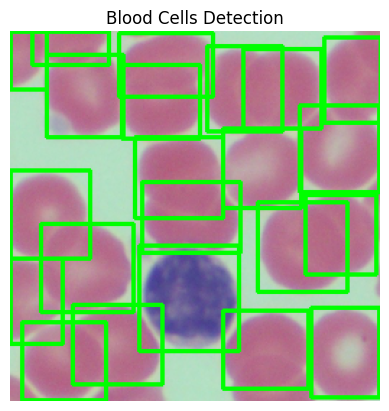

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_name = "image-100.png"

img_df = df[df['image'] == img_name]

img_path = dataset_path + "/images/" + img_name
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for _, row in img_df.iterrows():
    x1 = int(row['xmin'])
    y1 = int(row['ymin'])
    x2 = int(row['xmax'])
    y2 = int(row['ymax'])

    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

plt.imshow(img)
plt.title("Blood Cells Detection")
plt.axis('off')

Number of cells: 23


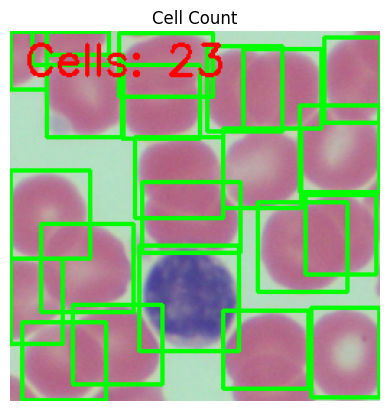

In [ ]:
output = img.copy()

count = len(img_df)

for _, row in img_df.iterrows():
    x1 = int(row['xmin'])
    y1 = int(row['ymin'])
    x2 = int(row['xmax'])
    y2 = int(row['ymax'])

    cv2.rectangle(output, (x1, y1), (x2, y2), (0,255,0), 2)

cv2.putText(output, f"Cells: {count}", (10,30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)

plt.imshow(output)
plt.title("Cell Count")
plt.axis('off')

print("Number of cells:", count)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

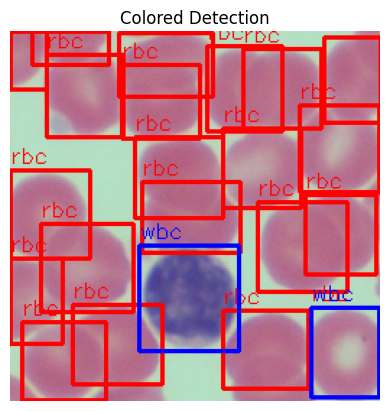

In [ ]:
output = img.copy()

for _, row in img_df.iterrows():
    x1 = int(row['xmin'])
    y1 = int(row['ymin'])
    x2 = int(row['xmax'])
    y2 = int(row['ymax'])
    label = row['label']

    if label == 'rbc':
        color = (255,0,0)
    elif label == 'wbc':
        color = (0,0,255)
    else:
        color = (0,255,0)

    cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)
    cv2.putText(output, label, (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

plt.imshow(output)
plt.title("Colored Detection")
plt.axis('off')

In [ ]:
# عدد كل نوع خلية
counts = df['label'].value_counts()

print(counts)

label
rbc    2237
wbc     103
Name: count, dtype: int64


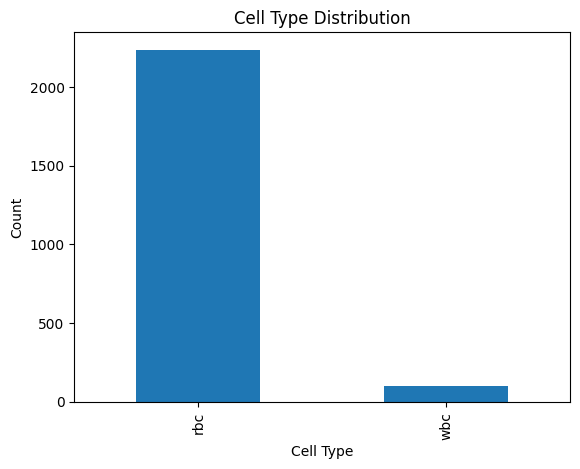

In [ ]:
import matplotlib.pyplot as plt

counts.plot(kind='bar')

plt.title("Cell Type Distribution")
plt.xlabel("Cell Type")
plt.ylabel("Count")

plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

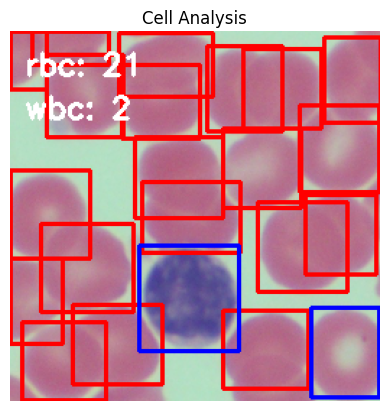

In [ ]:
output = img.copy()

type_counts = img_df['label'].value_counts()

for _, row in img_df.iterrows():
    x1 = int(row['xmin'])
    y1 = int(row['ymin'])
    x2 = int(row['xmax'])
    y2 = int(row['ymax'])
    label = row['label']

    if label == 'rbc':
        color = (255,0,0)
    elif label == 'wbc':
        color = (0,0,255)
    else:
        color = (0,255,0)

    cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)

y_pos = 30
for label, count in type_counts.items():
    text = f"{label}: {count}"
    cv2.putText(output, text, (10, y_pos),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
    y_pos += 30

plt.imshow(output)
plt.title("Cell Analysis")
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

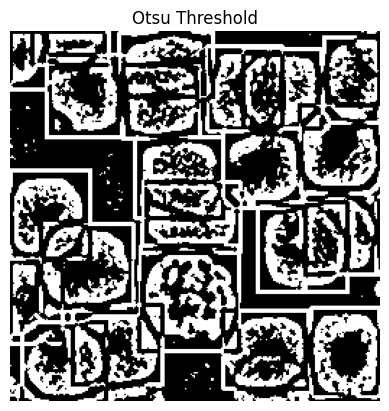

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

blur = cv2.GaussianBlur(enhanced, (5,5), 0)

thresh = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)
plt.imshow(thresh, cmap='gray')
plt.title("Otsu Threshold")
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

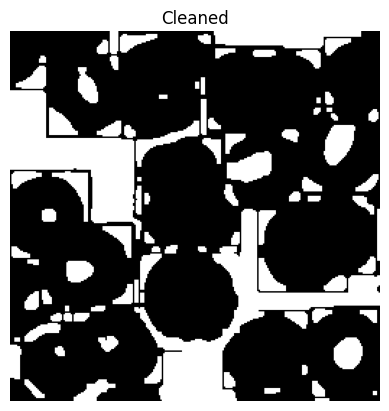

In [ ]:
kernel = np.ones((3,3), np.uint8)

sure_bg = cv2.dilate(thresh, kernel, iterations=2)

dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.29*dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)

markers = cv2.connectedComponents(sure_fg)[1]
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(img, markers)
plt.imshow(clean, cmap='gray')
plt.title("Cleaned")
plt.axis('off')

In [ ]:
dist = cv2.distanceTransform(clean, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(dist, 0.4*dist.max(), 255, 0)

sure_fg = np.uint8(sure_fg)

In [ ]:
kernel = np.ones((2,2), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

In [ ]:
output = img.copy()
count = 0

for m in np.unique(markers):
    if m <= 1:
        continue

    mask = np.uint8(markers == m)

    area = cv2.countNonZero(mask)

    if 350 < area < 3000:
        count += 1

In [ ]:
real_count = len(img_df)
detected_count = count

print("Ground Truth (CSV):", real_count)
print("Detected:", detected_count)

Ground Truth (CSV): 23
Detected: 24


In [ ]:
import os
import random

images_path = dataset_path + "/images"

all_images = os.listdir(images_path)

img_name = random.choice(all_images)

print("Testing on:", img_name)

Testing on: image-86.png


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

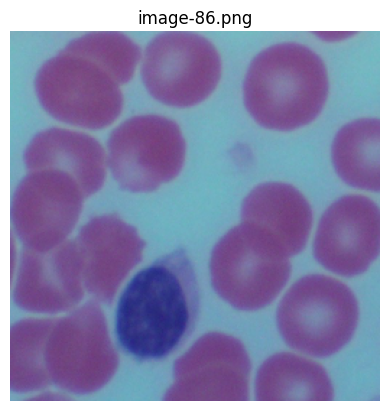

In [ ]:
img_path = images_path + "/" + img_name

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(img_name)
plt.axis('off')

In [ ]:
img_df = df[df['image'] == img_name]

real_count = len(img_df)
print("Ground Truth:", real_count)

Ground Truth: 20


In [ ]:
print("Detected:", count)

Detected: 24


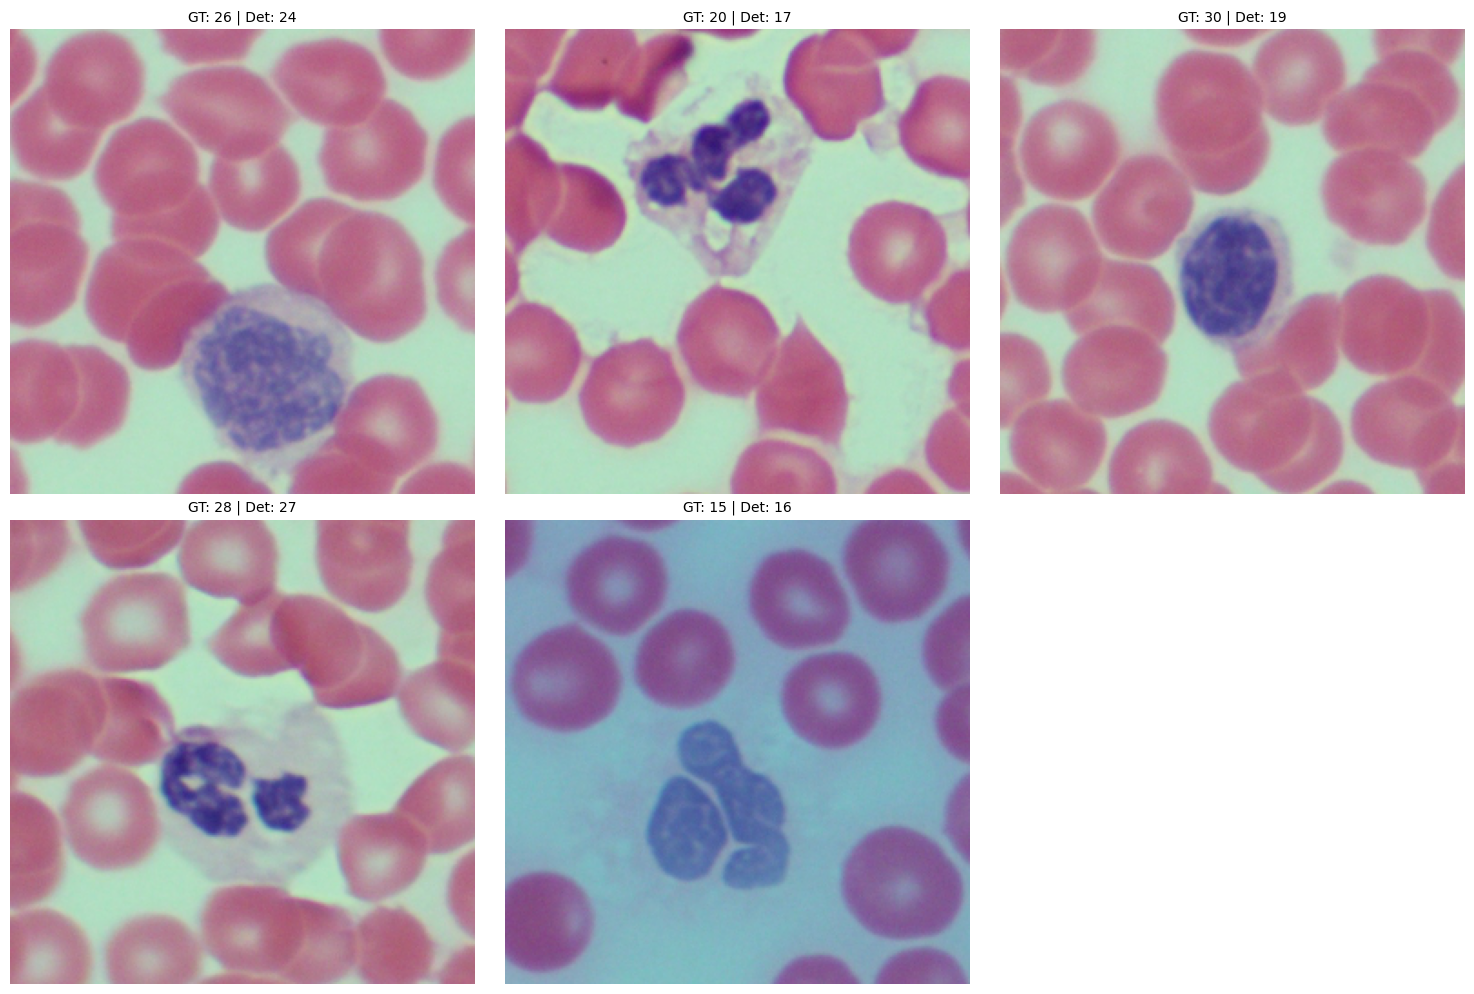

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
import os

images_path = dataset_path + "/images"

sample_images = random.sample(os.listdir(images_path), 5)

plt.figure(figsize=(15, 10))

for i, img_name in enumerate(sample_images):

    img_path = images_path + "/" + img_name
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_df = df[df['image'] == img_name]
    real_count = len(img_df)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    blur = cv2.GaussianBlur(enhanced, (5,5), 0)

    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    kernel = np.ones((3,3), np.uint8)

    sure_bg = cv2.dilate(thresh, kernel, iterations=2)

    dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.29*dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(sure_bg, sure_fg)

    markers = cv2.connectedComponents(sure_fg)[1]
    markers = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(img, markers)

    count = 0
    for m in np.unique(markers):
        if m <= 1:
            continue

        mask = np.uint8(markers == m)
        area = cv2.countNonZero(mask)

        if 350 < area < 3000:
            count += 1

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis('off')

    plt.title(f"GT: {real_count} | Det: {count}", fontsize=10)

plt.tight_layout()
plt.show()